In [ ]:
import numpy as np
import pandas as pd
import re
pd.options.mode.chained_assignment = None


In [ ]:
df = pd.read_csv('mail_data.csv')

In [ ]:
df.sample(5)

,Category,Message
779,ham,Happy New year my dear brother. I really do mi...
1561,ham,"Just got some gas money, any chance you and th..."
3516,ham,I'm job profile seems like bpo..
3719,ham,Cool. Do you like swimming? I have a pool and ...
1419,ham,Lmao. Take a pic and send it to me.


In [ ]:
df.shape

(5572, 2)

# 1. Data Cleaning

In [ ]:
df.info

<bound method DataFrame.info of      Category                                            Message
0         ham  Go until jurong point, crazy.. Available only ...
1         ham                      Ok lar... Joking wif u oni...
2        spam  Free entry in 2 a wkly comp to win FA Cup fina...
3         ham  U dun say so early hor... U c already then say...
4         ham  Nah I don't think he goes to usf, he lives aro...
...       ...                                                ...
5567     spam  This is the 2nd time we have tried 2 contact u...
5568      ham               Will ü b going to esplanade fr home?
5569      ham  Pity, * was in mood for that. So...any other s...
5570      ham  The guy did some bitching but I acted like i'd...
5571      ham                         Rofl. Its true to its name

[5572 rows x 2 columns]>

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [ ]:
df['Category'] = encoder.fit_transform(df['Category'])

In [ ]:
df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
# misssing values
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [ ]:
# check for duplicate values 
df.duplicated().sum()

415

In [ ]:
# Remove duplicates 
df = df.drop_duplicates(keep='first')

In [ ]:
df.duplicated().sum()

0

In [ ]:
df.shape

(5157, 2)

# 2. EDA

In [ ]:
df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df['Category'].value_counts()

Category
0    4516
1     641
Name: count, dtype: int64

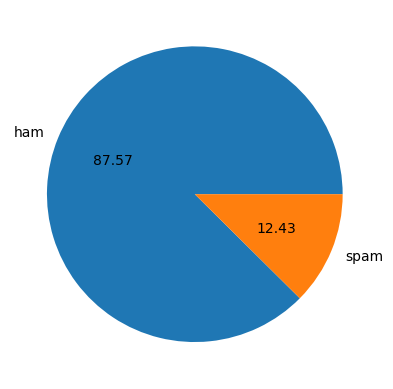

In [ ]:
import matplotlib.pyplot as plt
plt.pie(df['Category'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [ ]:
# Data is imbalanced

In [ ]:
import nltk

In [ ]:
!pip install nltk

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
 nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\deshm\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
df.loc[:, 'num_characters'] = df['Message'].apply(lambda x: len(str(x)))

In [ ]:
df.head()

,Category,Message,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [ ]:
df.loc[:, 'num_words'] = df['Message'].apply(lambda x: len(str(x).split()))

In [ ]:
df.head()

,Category,Message,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,20
1,0,Ok lar... Joking wif u oni...,29,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,0,U dun say so early hor... U c already then say...,49,11
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13


In [ ]:
df.loc[:, 'num_sentences'] = df['Message'].apply(lambda x: len(re.split(r'[.!?]+', str(x))) - 1)

In [ ]:
df.head()

,Category,Message,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,20,3
1,0,Ok lar... Joking wif u oni...,29,6,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,1
3,0,U dun say so early hor... U c already then say...,49,11,2
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,0


In [ ]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5157.000000,5157.000000,5157.000000
mean,79.103936,15.410704,1.858639
std,58.382922,11.118902,1.755847
min,2.000000,1.000000,0.000000
25%,36.000000,7.000000,1.000000
50%,61.000000,12.000000,2.000000
75%,118.000000,22.000000,3.000000
max,910.000000,171.000000,39.000000


In [ ]:
# ham messages data
df[df['Category'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.869353,14.239814,1.708592
std,56.708301,11.179471,1.696750
min,2.000000,1.000000,0.000000
25%,34.000000,7.000000,1.000000
50%,53.000000,11.000000,1.000000
75%,91.000000,19.000000,2.000000
max,910.000000,171.000000,39.000000


In [ ]:

import seaborn as sns 

<Axes: xlabel='num_characters', ylabel='Count'>

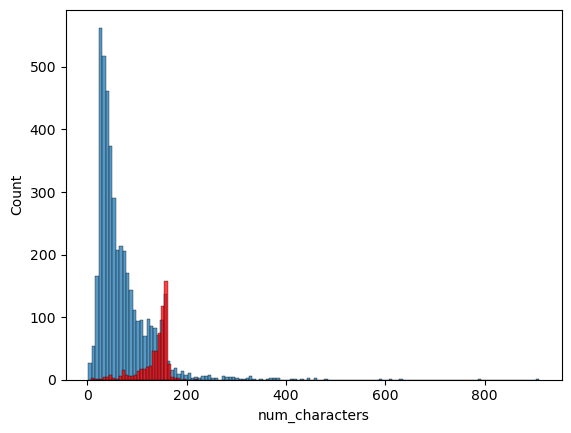

In [ ]:
sns.histplot(df[df['Category'] == 0]['num_characters'])
sns.histplot(df[df['Category'] == 1]['num_characters'],color ='red') 

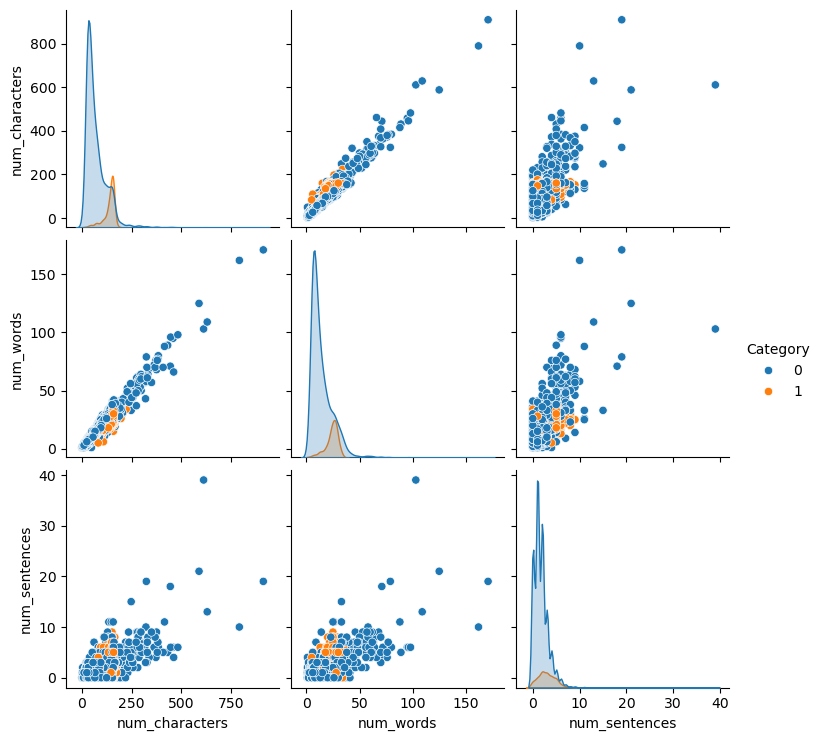

In [ ]:

sns.pairplot(df,hue='Category')

# 3. Data preprocessing

In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import string
def transform_Message(Message):
    Message =Message.lower()
    Message =nltk.word_tokenize(Message)
    
    y=[]
    for i in Message:
        if i.isalnum():
            y.append(i)
            
    Message = y[:]
    y.clear()

    for i in Message:
          if i not in ENGLISH_STOP_WORDS and i not in string.punctuation:
            y.append(i)
            
    return y

In [ ]:
transform_Message('I loved YT lectures on machine leaning. how about you?')

['loved', 'yt', 'lectures', 'machine', 'leaning']

In [ ]:
df['transformed_Message'] =  df['Message'].apply(transform_Message)


In [ ]:
df.head()

,Category,Message,num_characters,num_words,num_sentences,transformed_Message
0,0,"Go until jurong point, crazy.. Available only ...",111,20,3,"[jurong, point, crazy, available, bugis, n, gr..."
1,0,Ok lar... Joking wif u oni...,29,6,2,"[ok, lar, joking, wif, u, oni]"
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,1,"[free, entry, 2, wkly, comp, win, fa, cup, fin..."
3,0,U dun say so early hor... U c already then say...,49,11,2,"[u, dun, say, early, hor, u, c, say]"
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,0,"[nah, think, goes, usf, lives]"


# 4. Model Building

In [ ]:
print(df['transformed_Message'].dtype)
print(df['transformed_Message'].head())

object
0    [jurong, point, crazy, available, bugis, n, gr...
1                       [ok, lar, joking, wif, u, oni]
2    [free, entry, 2, wkly, comp, win, fa, cup, fin...
3                 [u, dun, say, early, hor, u, c, say]
4                       [nah, think, goes, usf, lives]
Name: transformed_Message, dtype: object


In [ ]:
df['transformed_Message'] = df['transformed_Message'].astype(str)

In [ ]:
df['transformed_Message'] = df['transformed_Message'].fillna("")

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer()

In [ ]:
X = tfidf.fit_transform(df['transformed_Message']).toarray()

In [ ]:
X.shape

(5157, 7939)

In [ ]:
y = df['Category'].values

In [ ]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [ ]:
 from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [ ]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [ ]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [ ]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8788759689922481
[[798 107]
 [ 18 109]]
0.5046296296296297


In [ ]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9602713178294574
[[905   0]
 [ 41  86]]
1.0


In [ ]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9709302325581395
[[902   3]
 [ 27 100]]
0.970873786407767


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50, random_state=2)

In [ ]:
clfs = {
    'SVC' : svc,
    'KN' : knc,
    'NB' : mnb,
    'DT' : dtc,
    'LR' : lrc,
    'RF' : rfc,
    'BgC' : bc,
    'ETF' : etc,
    'GBDT' : gbdt
}

In [ ]:
 def train_classifier(clf,X_train,y_train,X_test,y_test):
     clf.fit(X_train,y_train)
     y_pred = clf.predict(X_test)
     
     accuracy = accuracy_score(y_test,y_pred)
     precision = precision_score(y_test,y_pred)
     
     return accuracy,precision

In [ ]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9757751937984496, 0.9903846153846154)

In [ ]:
accuracy_scores = []
precision_scores = []

In [ ]:
selected_models = ['SVC', 'NB', 'RF']
for name in selected_models:
    clf = clfs[name]
    current_accuracy, current_precision = train_classifier(clf, X_train, y_train, X_test, y_test)
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)


In [ ]:
selected_models = ['ETF', 'KN', 'DT']
for name in selected_models:
    clf = clfs[name]
    current_accuracy, current_precision = train_classifier(clf, X_train, y_train, X_test, y_test)
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

In [ ]:
print(accuracy_scores)
print(precision_scores)

[0.9757751937984496, 0.9602713178294574, 0.9670542635658915, 0.9709302325581395, 0.9031007751937985, 0.9273255813953488]
[0.9903846153846154, 1.0, 1.0, 1.0, 1.0, 0.8333333333333334]


In [ ]:
print(len(clfs.keys()), len(accuracy_scores), len(precision_scores))

9 6 6


In [ ]:
min_length = min(len(clfs.keys()), len(accuracy_scores), len(precision_scores))
temp_df = pd.DataFrame({
    'Algorithm': list(clfs.keys())[:min_length],
    'Accuracy_scores': accuracy_scores[:min_length],
    'Precision_scores': precision_scores[:min_length]
})

In [ ]:
print(temp_df)

  Algorithm  Accuracy_scores  Precision_scores
0       SVC         0.975775          0.990385
1        KN         0.960271          1.000000
2        NB         0.967054          1.000000
3        DT         0.970930          1.000000
4        LR         0.903101          1.000000
5        RF         0.927326          0.833333


In [ ]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))